Hands-On Lab: Reducing Dimensions with PCA      
● Step 1: Scale a high-dimensional provided dataset with StandardScaler.        
● Step 2: Fit PCA and plot the cumulative explained variance against the number of components.      
● Step 3: Choose the number of components that retains ~95% of the variance and justify it.     
● Step 4: Reduce the data to 2 components and produce a 2D scatter plot, coloring points by a known group if available.         
● Step 5: Document what the reduction preserved and what it cost in Markdown.       

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#### Load & clean data:

In [100]:
df = pd.read_csv("cardiac arrest dataset-selected-columns.csv")

In [109]:

print("Original shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().copy()
print("Shape after removing duplicates:", df.shape)

df.head()

Original shape: (302, 11)
Missing values: 0
Duplicate rows: 0
Shape after removing duplicates: (302, 11)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,target
0,52,1,0,125,212,0,1,168,0,1.0,0
1,53,1,0,140,203,1,0,155,1,3.1,0
2,70,1,0,145,174,0,1,125,1,2.6,0
3,61,1,0,148,203,0,1,161,0,0.0,0
4,62,0,0,138,294,1,1,106,0,1.9,0


In [110]:
X = df.drop(columns=["target"]).copy()
y = df["target"].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X.shape)
print("Scaled matrix shape:", X_scaled.shape)
print("Features:", list(X.columns))

Feature matrix shape: (302, 10)
Scaled matrix shape: (302, 10)
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']


#### PCA


Finds new axes — "principal components" — that capture the directions of 
greatest variance in the data.

- The first component captures the most variance.
- The second the next most.(perpendicular to the first), and so..

##### Fit the model

In [131]:
pca = PCA(n_components=9) # instanciate model
X_pca = pca.fit_transform(X_scaled) 

print("Before PCA shape:", X.shape)
print ("After PCA shape:", X_pca.shape)

Before PCA shape: (302, 10)
After PCA shape: (302, 9)


##### Explained varinace

In [135]:
explained = pca.explained_variance_ratio_

cumulative = np.cumsum(explained) # cumsum() : returns the cumulative sum (running total) of elements.

print("Explained variance per component:")
print(np.round(explained, 4))

print(f"Cumulative variance retained: {cumulative[-1]:.4f}")


Explained variance per component:
[0.219  0.1503 0.1185 0.1035 0.087  0.0824 0.0719 0.0683 0.0563]
Cumulative variance retained: 0.9573


**Explained variance**  
How much of the data's total information each component keeps.

- Summing these tells you how much you retained after reduction.

- A common rule: **'keep enough components to retain about 95% of the variance'** .

**To keep 95% variance** :

In [ ]:
for i in range(1, len(X.columns)+1):
    
    pca1 = PCA(n_components=i)
    pca1.fit(X_scaled)

    print("Number of components:", i)
    print(pca1.explained_variance_ratio_)        # variance explained by each component
    print(pca1.explained_variance_ratio_.sum()) # total variance retained
    print()

Number of components: 1
[0.21904786]
0.21904786237375115

Number of components: 2
[0.21904786 0.15029285]
0.36934070913807504

Number of components: 3
[0.21904786 0.15029285 0.11854971]
0.4878904211516485

Number of components: 4
[0.21904786 0.15029285 0.11854971 0.1034698 ]
0.5913602165397979

Number of components: 5
[0.21904786 0.15029285 0.11854971 0.1034698  0.08698931]
0.6783495240685695

Number of components: 6
[0.21904786 0.15029285 0.11854971 0.1034698  0.08698931 0.08244355]
0.7607930768051892

Number of components: 7
[0.21904786 0.15029285 0.11854971 0.1034698  0.08698931 0.08244355
 0.07189726]
0.8326903375306954

Number of components: 8
[0.21904786 0.15029285 0.11854971 0.1034698  0.08698931 0.08244355
 0.07189726 0.06829534]
0.9009856759392842

Number of components: 9
[0.21904786 0.15029285 0.11854971 0.1034698  0.08698931 0.08244355
 0.07189726 0.06829534 0.05629924]
0.9572849186773135

Number of components: 10
[0.21904786 0.15029285 0.11854971 0.1034698  0.08698931 0.082

The closest we can get to retaining ~95% of the variance is when the Number of components: 9 .

Keeping all 10 components would retain 100% of the variance, but it would defeat the purpose of PCA because no dimensionality reduction would be achieved.

By choosing 9 components, we reduce the dataset by one dimension while still retaining 96.41% of the total variance

##### Visualization:

**Number of componenets vs explained variance**


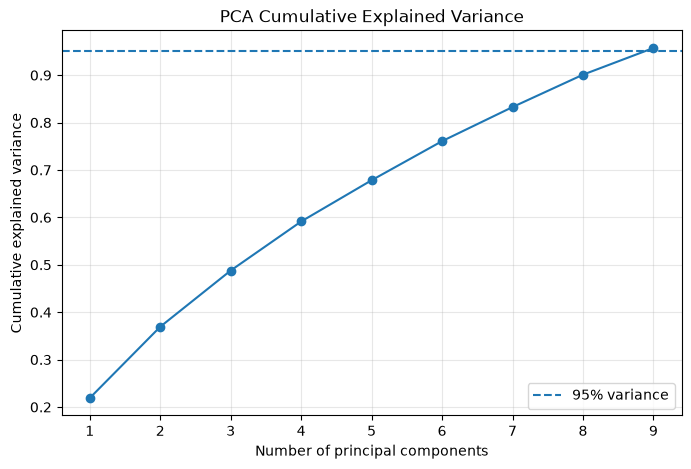

In [ ]:

components = np.arange(1, len(cumulative) + 1)

plt.figure(figsize=(8, 5))

plt.plot(components, cumulative, marker="o")

plt.axhline(0.95, linestyle="--", label="95% variance")

plt.xticks(components)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")

plt.title("PCA Cumulative Explained Variance")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### Heatmap:

To visualize(represent) the correlation among principal components(new), and the original features.

In [146]:
print(pca.components_)

[[-0.3911262  -0.06269085  0.34234823 -0.2346995  -0.1677544  -0.0758686
   0.16284177  0.49247122 -0.44110743 -0.41627552]
 [ 0.364713   -0.36044984  0.35652953  0.45730588  0.37808267  0.31066895
  -0.21618271  0.14712589 -0.29998508 -0.05463165]
 [-0.05574939  0.59024926  0.27960241  0.23341265 -0.44328324  0.52396769
  -0.15545859  0.04867519  0.00639114  0.13497839]
 [ 0.2652056  -0.21378719  0.23604888  0.11570739 -0.37064509 -0.03118213
   0.73263693 -0.26718049 -0.15987851  0.20688213]
 [-0.03885956 -0.20547798 -0.30793232 -0.16236026  0.05670328  0.71009856
   0.2971984  -0.03546881  0.2389228  -0.42539547]
 [-0.45075637 -0.02026445 -0.11048548  0.50604601  0.22540586 -0.01759287
   0.35460998  0.42340106  0.27846058  0.30731765]
 [ 0.09974998  0.43621045  0.28326076 -0.41514534  0.62326643  0.12105494
   0.31314346 -0.00636702 -0.05471645  0.20731492]
 [-0.34310689 -0.48136516  0.24320571 -0.38103931 -0.0862884   0.26725485
  -0.23113575 -0.06610079  0.07110404  0.55182026]
 

**In this numpy matrix array:**    
 
 each row represents a principal component,     
  and each column relates back to the original features.

<Axes: >

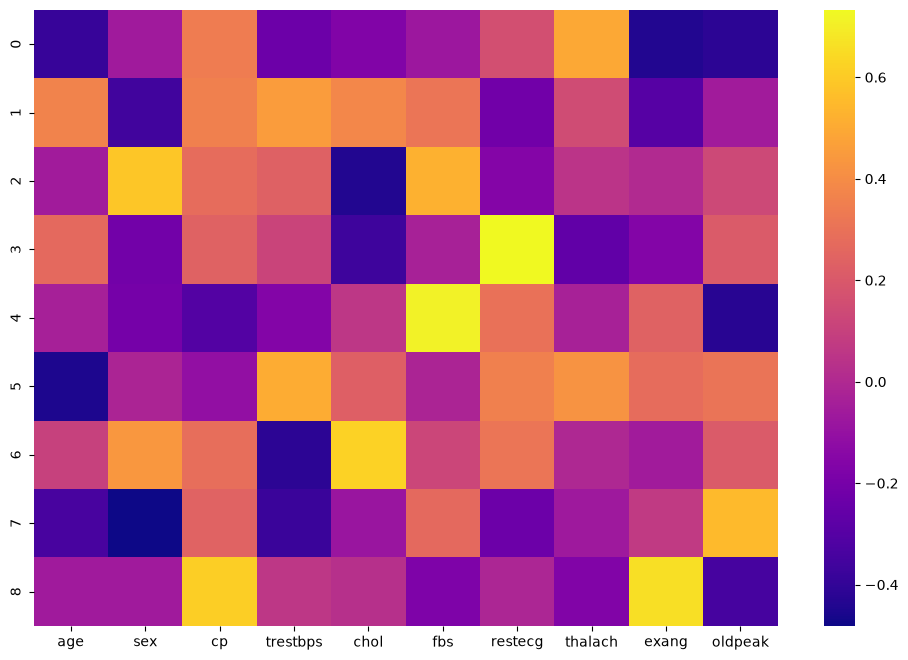

In [147]:
df_components = pd.DataFrame(pca.components_, columns = X.columns)

plt.figure(figsize=(12,8))
sns.heatmap(df_components, cmap='plasma')